# Dataset Exploration

## 1. Import Libraries

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# Location of raw dataset
data_dir = Path("../data/raw/Dataset (With Summer GT)")

## 2. Load Example Tree

In [3]:
summer_rgb_path = data_dir / "R01N01_Summer_RGB-12-40-50.png"
summer_depth_path = data_dir / "R01N01_Summer_D-12-40-50.png"
summer_gt_path = data_dir / "R01N01_Summer_GT-12-40-50.png"

winter_rgb_path = data_dir / "R01N01_Winter_RGB-11-23-49.png"
winter_depth_path = data_dir / "R01N01_Winter_D-11-23-49.png"

## 3. Inspect Image Properties

In [19]:
# Load images as NumPy arrays
summer_rgb = np.array(Image.open(summer_rgb_path))
summer_depth = np.array(Image.open(summer_depth_path))
summer_gt = np.array(Image.open(summer_gt_path))

winter_rgb = np.array(Image.open(winter_rgb_path))
winter_depth = np.array(Image.open(winter_depth_path))


# Inspect image properties
print("Summer RGB:")
print("  Shape:", summer_rgb.shape)
print("  Data type:", summer_rgb.dtype)

print("\nSummer Depth:")
print("  Shape:", summer_depth.shape)
print("  Data type:", summer_depth.dtype)
print("  Minimum:", summer_depth.min())
print("  Maximum:", summer_depth.max())

print("\nSummer Ground Truth:")
print("  Shape:", summer_gt.shape)
print("  Data type:", summer_gt.dtype)
print("  Unique values:", np.unique(summer_gt))

print("\nWinter RGB:")
print("  Shape:", winter_rgb.shape)
print("  Data type:", winter_rgb.dtype)

print("\nWinter Depth:")
print("  Shape:", winter_depth.shape)
print("  Data type:", winter_depth.dtype)
print("  Minimum:", winter_depth.min())
print("  Maximum:", winter_depth.max())

Summer RGB:
  Shape: (480, 640, 3)
  Data type: uint8

Summer Depth:
  Shape: (480, 640, 3)
  Data type: uint8
  Minimum: 0
  Maximum: 169

Summer Ground Truth:
  Shape: (256, 256)
  Data type: uint8
  Unique values: [  0 255]

Winter RGB:
  Shape: (480, 640, 3)
  Data type: uint8

Winter Depth:
  Shape: (480, 640, 3)
  Data type: uint8
  Minimum: 0
  Maximum: 145


### Notes
- Note that the ground truth has a different size then the other images

## 4. Visualise RGB, Depth and Ground Truth

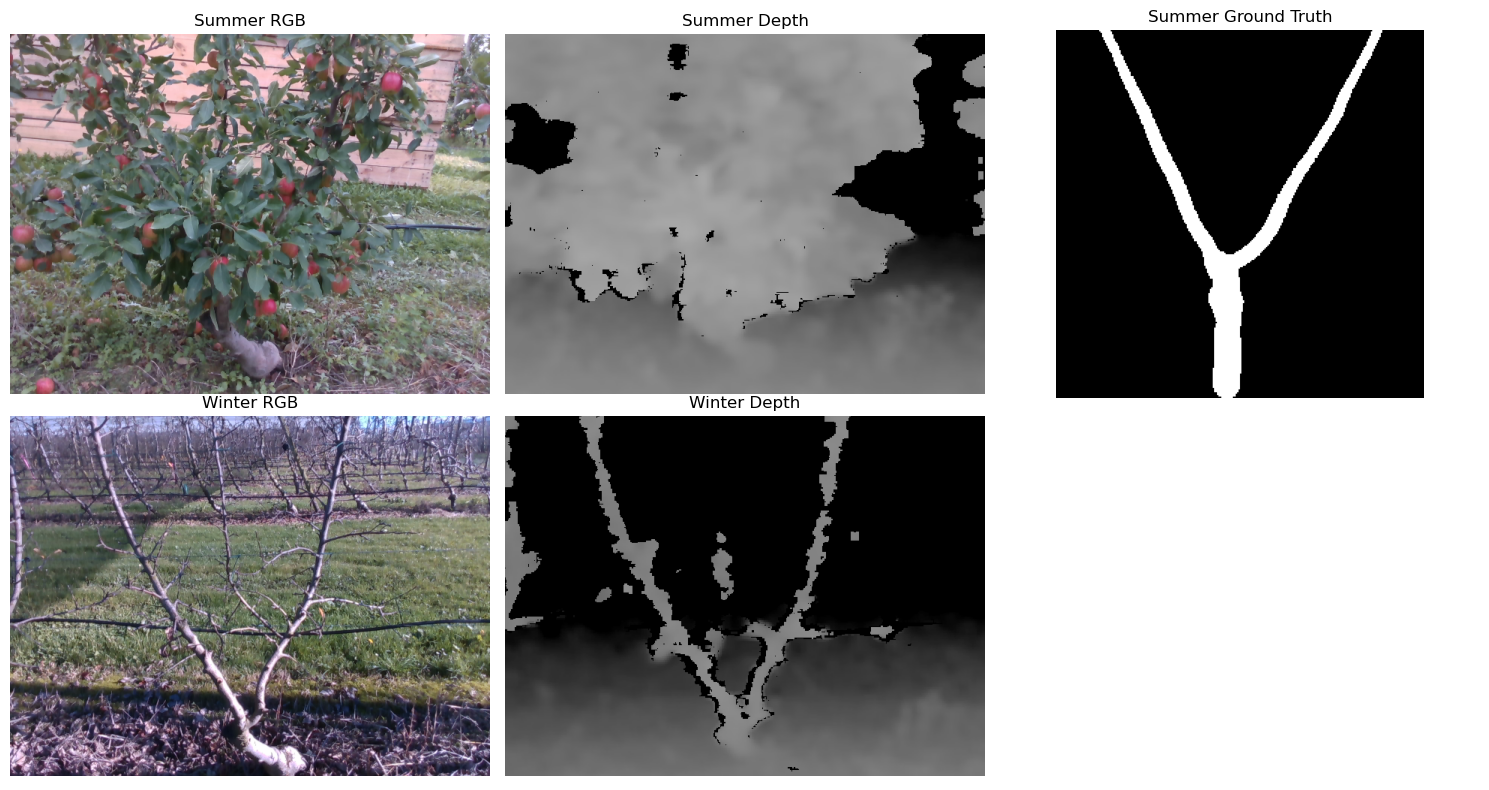

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(summer_rgb)
axes[0, 0].set_title("Summer RGB")

axes[0, 1].imshow(summer_depth, cmap="gray")
axes[0, 1].set_title("Summer Depth")

axes[0, 2].imshow(summer_gt, cmap="gray")
axes[0, 2].set_title("Summer Ground Truth")

axes[1, 0].imshow(winter_rgb)
axes[1, 0].set_title("Winter RGB")

axes[1, 1].imshow(winter_depth, cmap="gray")
axes[1, 1].set_title("Winter Depth")

axes[1, 2].axis("off")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Observations

- The summer and winter RGB images show the same tree under different seasonal conditions.
- The depth images contain information about the distance between the camera and objects in the scene.
- The summer ground truth provides labelled information that can be used when evaluating the reconstruction.
- The summer image contains substantially more foliage than the winter image, which may affect the visibility of the tree structure.

## 5. Analyse Depth Data

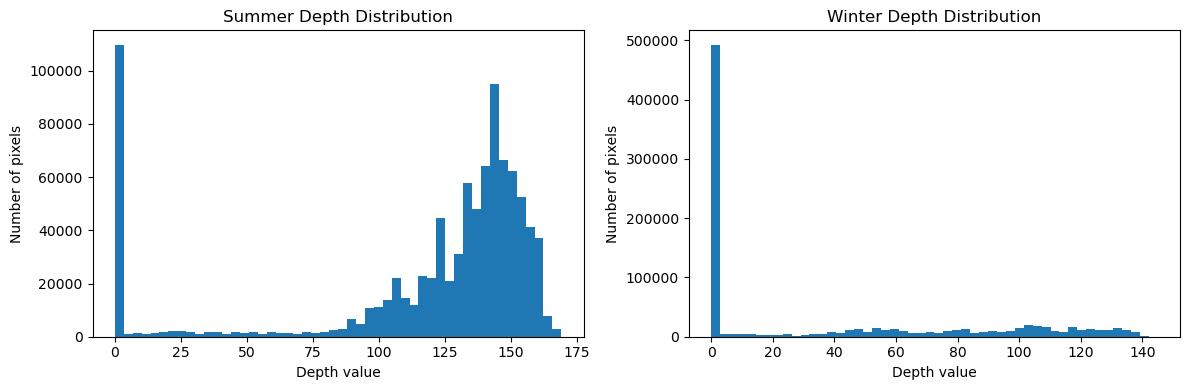

Summer depth channels equal:
Channel 0 = Channel 1: True
Channel 1 = Channel 2: True

Winter depth channels equal:
Channel 0 = Channel 1: True
Channel 1 = Channel 2: True


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(summer_depth.flatten(), bins=50)
axes[0].set_xlabel("Depth value")
axes[0].set_ylabel("Number of pixels")
axes[0].set_title("Summer Depth Distribution")

axes[1].hist(winter_depth.flatten(), bins=50)
axes[1].set_xlabel("Depth value")
axes[1].set_ylabel("Number of pixels")
axes[1].set_title("Winter Depth Distribution")

plt.tight_layout()
plt.show()
# Check whether the three depth channels contain the same information

print("Summer depth channels equal:")
print("Channel 0 = Channel 1:",
      np.array_equal(summer_depth[:, :, 0], summer_depth[:, :, 1]))
print("Channel 1 = Channel 2:",
      np.array_equal(summer_depth[:, :, 1], summer_depth[:, :, 2]))

print("\nWinter depth channels equal:")
print("Channel 0 = Channel 1:",
      np.array_equal(winter_depth[:, :, 0], winter_depth[:, :, 1]))
print("Channel 1 = Channel 2:",
      np.array_equal(winter_depth[:, :, 1], winter_depth[:, :, 2]))
summer_depth = summer_depth[:, :, 0]
winter_depth = winter_depth[:, :, 0]

### Depth observations

- The depth distributions provide an initial indication of the range and frequency of depth measurements in the scene. These depth values will later be used to reconstruct the tree in three dimensions.

## 6. Analyse Ground Truth

Ground Truth Properties
Shape: (256, 256)
Data type: uint8
Unique values: [  0 255]

Background pixels: 60321
Foreground pixels: 5215
Foreground percentage: 7.96 %


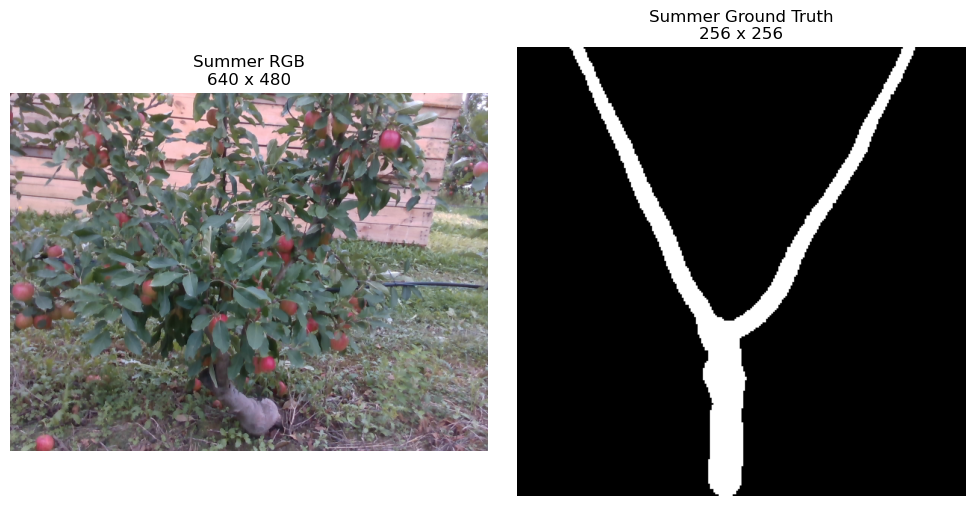

In [27]:
# Analyse ground truth

print("Ground Truth Properties")
print("Shape:", summer_gt.shape)
print("Data type:", summer_gt.dtype)
print("Unique values:", np.unique(summer_gt))


# Count background and foreground pixels
background_pixels = np.sum(summer_gt == 0)
foreground_pixels = np.sum(summer_gt == 255)

total_pixels = summer_gt.size

print("\nBackground pixels:", background_pixels)
print("Foreground pixels:", foreground_pixels)
print(
    "Foreground percentage:",
    round(100 * foreground_pixels / total_pixels, 2),
    "%"
)


# Display RGB and ground truth separately
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(summer_rgb)
axes[0].set_title(f"Summer RGB\n{summer_rgb.shape[1]} x {summer_rgb.shape[0]}")

axes[1].imshow(summer_gt, cmap="gray")
axes[1].set_title(
    f"Summer Ground Truth\n{summer_gt.shape[1]} x {summer_gt.shape[0]}"
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Ground Truth Observations

The summer ground-truth image is a binary image containing pixel values of 0 and 255. This indicates two labelled classes within the ground-truth data.

The ground-truth image has a resolution of 256 × 256 pixels, while the RGB and depth observations have a resolution of 640 × 480 pixels. Therefore, the ground truth cannot be directly overlaid onto the RGB image without determining the spatial relationship between the two image formats.

This difference in resolution and aspect ratio will need to be considered when the ground truth is used for validation later in the project.

## 7. Dataset Structure and Pairing

In [24]:
class Tree:
    """
    Stores the RGB, depth and ground-truth data associated with one tree.
    """

    def __init__(self, tree_id, data_dir):
        self.tree_id = tree_id
        self.data_dir = Path(data_dir)

        # Find all files belonging to this tree
        self.files = list(self.data_dir.glob(f"{tree_id}_*.png"))

        # Find image paths
        self.summer_rgb_path = self.find_file("Summer_RGB")
        self.summer_depth_path = self.find_file("Summer_D")
        self.summer_gt_path = self.find_file("Summer_GT")

        self.winter_rgb_path = self.find_file("Winter_RGB")
        self.winter_depth_path = self.find_file("Winter_D")

        # Load images
        self.summer_rgb = self.load_image(self.summer_rgb_path)
        self.summer_depth = self.load_image(self.summer_depth_path)
        self.summer_gt = self.load_image(self.summer_gt_path)

        self.winter_rgb = self.load_image(self.winter_rgb_path)
        self.winter_depth = self.load_image(self.winter_depth_path)


    def find_file(self, keyword):
        """Find a file belonging to the tree containing the given keyword."""

        for file in self.files:
            if keyword in file.name:
                return file

        return None


    def load_image(self, path):
        """Load an image as a NumPy array."""

        if path is None:
            return None

        return np.array(Image.open(path))


class TreeDataset:
    """
    Stores information about the complete tree dataset.
    """

    def __init__(self, data_dir):
        self.data_dir = Path(data_dir)

        # Find all PNG files
        self.file_list = list(self.data_dir.glob("*.png"))

        # Get unique tree IDs
        self.tree_names = sorted(
            set(file.name[:6] for file in self.file_list)
        )

        self.number_of_images = len(self.file_list)
        self.number_of_trees = len(self.tree_names)


    def get_tree(self, tree_id):
        """Return a Tree object for a given tree ID."""

        return Tree(tree_id, self.data_dir)


# Create dataset
dataset = TreeDataset(data_dir)

print("Number of images:", dataset.number_of_images)
print("Number of trees:", dataset.number_of_trees)
print("Tree IDs:", dataset.tree_names)


# Test that an individual tree can be accessed
tree = dataset.get_tree("R01N01")

print("\nExample tree:", tree.tree_id)
print("Summer RGB shape:", tree.summer_rgb.shape)
print("Summer depth shape:", tree.summer_depth.shape)

Number of images: 2810
Number of trees: 562
Tree IDs: ['R01N01', 'R01N02', 'R01N03', 'R01N04', 'R01N05', 'R01N06', 'R01N07', 'R01N08', 'R01N09', 'R01N10', 'R01N11', 'R01N12', 'R01N13', 'R01N14', 'R01N15', 'R01N16', 'R01N17', 'R01N18', 'R01N19', 'R01N20', 'R01N21', 'R01N22', 'R01N23', 'R01N24', 'R01N25', 'R01N26', 'R01N27', 'R01N28', 'R01N29', 'R01N30', 'R01N31', 'R01N32', 'R01N33', 'R01N34', 'R01N35', 'R01N36', 'R01N37', 'R01N38', 'R01N39', 'R01N40', 'R01N41', 'R01N42', 'R01N43', 'R01N44', 'R02N01', 'R02N02', 'R02N03', 'R02N04', 'R02N05', 'R02N06', 'R02N07', 'R02N08', 'R02N09', 'R02N10', 'R02N11', 'R02N12', 'R02N13', 'R02N14', 'R02N15', 'R02N16', 'R02N17', 'R02N18', 'R02N19', 'R02N20', 'R02N21', 'R02N22', 'R02N23', 'R02N24', 'R02N25', 'R02N26', 'R02N27', 'R02N28', 'R02N29', 'R02N30', 'R02N31', 'R02N32', 'R02N33', 'R02N34', 'R02N35', 'R02N36', 'R02N37', 'R02N38', 'R02N39', 'R02N40', 'R02N41', 'R02N42', 'R02N43', 'R03N01', 'R03N02', 'R03N03', 'R03N04', 'R03N05', 'R03N06', 'R03N07', 'R03N

## Analyze total data using classes

RGB: (480, 640, 3) uint8
Depth: (480, 640, 3) uint8
Depth range: 0 169
GT: (256, 256) uint8
GT values: [  0 255]


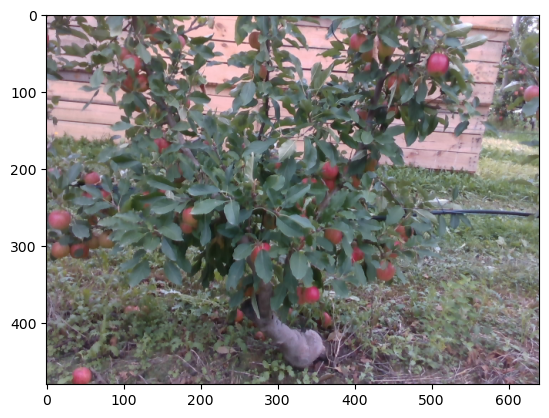

In [17]:
print("RGB:", tree.summer_rgb.shape, tree.summer_rgb.dtype)

print("Depth:", tree.summer_depth.shape, tree.summer_depth.dtype)
print("Depth range:", tree.summer_depth.min(), tree.summer_depth.max())

print("GT:", tree.summer_gt.shape, tree.summer_gt.dtype)
print("GT values:", np.unique(tree.summer_gt))

tree1 = dataset.get_tree("R01N01")


plt.imshow(tree1.summer_rgb)
plt.show()

## 8. Check Dataset Completeness


In [25]:
missing_files = []

for tree_id in dataset.tree_names:

    tree = dataset.get_tree(tree_id)

    if tree.summer_rgb is None:
        missing_files.append((tree_id, "Summer RGB"))

    if tree.summer_depth is None:
        missing_files.append((tree_id, "Summer Depth"))

    if tree.summer_gt is None:
        missing_files.append((tree_id, "Summer Ground Truth"))

    if tree.winter_rgb is None:
        missing_files.append((tree_id, "Winter RGB"))

    if tree.winter_depth is None:
        missing_files.append((tree_id, "Winter Depth"))


if len(missing_files) == 0:
    print("Dataset complete: no missing files found.")

else:
    print("Missing files:")

    for tree_id, file_type in missing_files:
        print(tree_id, "-", file_type)

Dataset complete: no missing files found.


## 9. Exploration Summary

The initial exploration identified 2810 images representing 562 individual trees.

Each tree contains summer RGB, summer depth, summer ground-truth, winter RGB and winter depth data. The RGB images have a resolution of 480 X 640, while the depth images contain numerical depth information describing the observed scene.

The ground-truth data provides reference information about the tree structure and will be used later to evaluate the computational reconstruction.

The summer and winter observations show the trees under different seasonal conditions. In particular, the presence of foliage in the summer observations changes the visibility of branches compared with the winter observations.

The dataset completeness check identified no missing files. 

As the summer trees have a lot of foliage covering the branches i will be using the winter observations to recreate the branch structure in the project. 